In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content
!git clone https://github.com/agataben/bitenet.git
%cd bitenet
!git checkout main

/content
Cloning into 'bitenet'...
remote: Enumerating objects: 41573, done.
remote: Counting objects: 100% (287/287), done.
remote: Compressing objects: 100% (132/132), done.
remote: Total 41573 (delta 201), reused 210 (delta 151), pack-reused 41286 (from 2)
Receiving objects: 100% (41573/41573), 1.86 GiB | 36.02 MiB/s, done.
Resolving deltas: 100% (310/310), done.
/content/bitenet
Already on 'main'
Your branch is up to date with 'origin/main'.


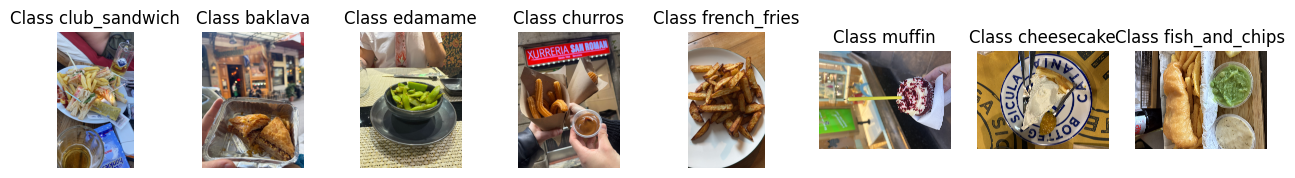

In [3]:
from src.utils import plot_dataset

dataset_path = '/content/drive/MyDrive/data/samples'
plot_dataset(dataset_path)

In [8]:
import torch
from src.bitenet_v1 import BiteNetV1

ckpt_file_path = '/content/drive/MyDrive/results/bitenetv1/model/exp_1_1-19.pth'
ckpt_file = torch.load(ckpt_file_path, map_location=torch.device('cpu'))
norm_params_file_path = '/content/drive/MyDrive/data'

model = BiteNetV1()
model.path_to_norm_params_file = norm_params_file_path
model.load_state_dict(ckpt_file['model'])
model.eval()

BiteNetV1(
  (conv_1): Sequential(
    (0): Conv2d(3, 18, kernel_size=(6, 6), stride=(2, 2))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU()
  )
  (conv_2): Sequential(
    (0): Conv2d(18, 28, kernel_size=(5, 5), stride=(2, 2))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU()
  )
  (conv_3): Sequential(
    (0): Conv2d(28, 28, kernel_size=(3, 3), stride=(2, 2))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU()
  )
  (classifier): Linear(in_features=252, out_features=101, bias=True)
)

In [11]:
import os
from glob import glob

img_paths = glob(os.path.join(dataset_path, '*.jpg'))
for path in img_paths:
  model.predict(path)

Class 21
Class 25
Class 20
Class 26
Class 22
Class 22
Class 18
Class 15
